<a href="https://colab.research.google.com/github/pavithra130608/Pavi/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-7-1f0df8d656a7>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].replace({'Yes': 1, 'No': 0}).astype(int)


Accuracy :  90.11611049196677
Enter number of BHKs (e.g., 2, 3, 4): 4
Enter Price per SQFT: 4000
Predicted Price: ₹404,913,229.37

Matching Property Details:
                                         Name  \
5117     Total Environment Reach For The Sky   
6122       Jai Jawan Colony, Kapra,Hyderabad   
11186  Hingane Home Colony, Karve Nagar,Pune   
11969                   Manjari Budruk, Pune   
14030                Anand Parbat, New Delhi   
14514         Block D, Preet Vihar,New Delhi   

                                          Property Title      Price  \
5117   4 BHK Independent House for sale in Indira Nag...   12000000   
6122   4 BHK Independent House for sale in Kapra, Hyd...   12000000   
11186  4 BHK Independent House for sale in Karve Naga...  600000000   
11969  4 BHK Independent House for sale in Manjari Bu...  280000000   
14030  4 BHK Independent House for sale in Anand Parb...   10000000   
14514  4 BHK Independent House for sale in Preet Viha...  400000000   

      

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


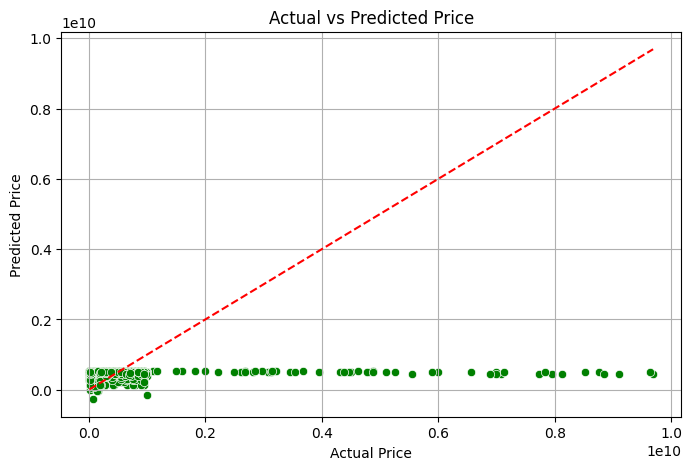

<ipython-input-7-1f0df8d656a7>:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Property Size', y='Price_per_SQFT', data=df, palette='pastel')


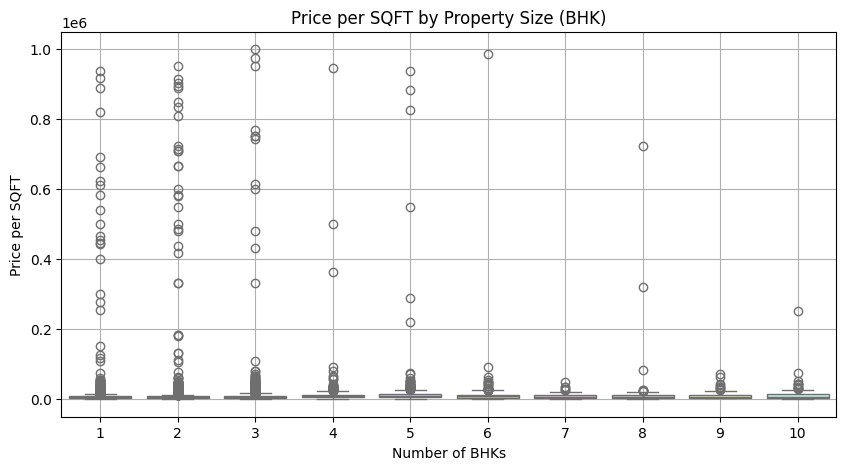

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_dataset.csv')
df.head(20)

#clean
c=['Balcony']
df[c] = df[c].replace({'Yes': 1, 'No': 0}).astype(int)
df.head(20)


# Extract digits from 'Property Size'
df['Property Size'] = df['Property Size'].str.extract(r'(\d+)')

# Drop rows where 'Property Size' could not be extracted
df = df.dropna(subset=['Property Size'])

# Convert to integer
df['Property Size'] = df['Property Size'].astype(int)

# Now check
df.head(20)

#declare X and y
X = df[['Property Size', 'Price_per_SQFT']]
y = df['Price']


#train and testing  random values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#fitting into LR
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#predicting values
y_pred = lr_model.predict(X_test)
lr_y_pred = lr_model.predict(X_test)


#accuracy
r_accuracy = r2_score(y_test, lr_y_pred)*10000
print('Accuracy : ',r_accuracy)

property_size = int(input("Enter number of BHKs (e.g., 2, 3, 4): "))
price_per_sqft = int(input("Enter Price per SQFT: "))

# Predict
input_data = [[property_size, price_per_sqft]]
predicted_price = lr_model.predict(input_data)

# Avoid negative prices
predicted_price = max(predicted_price[0], 0)

print(f"Predicted Price: ₹{predicted_price:,.2f}")

# Finding closest match in the dataset
matching_row = df.loc[(df['Property Size'] == property_size) & (df['Price_per_SQFT'] == price_per_sqft)]

# Print entire row if found, otherwise show a message
if not matching_row.empty:
    print("\nMatching Property Details:\n", matching_row)
else:
    print("\nNo exact match found in the dataset.")
    print("\nNo exact match found in the dataset.")

#data visualisation
#Scatter Plot - Actual vs Predicted Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='green')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.grid(True)
plt.show()

#Boxplot - Price per SQFT across Property Size
plt.figure(figsize=(10, 5))
sns.boxplot(x='Property Size', y='Price_per_SQFT', data=df, palette='pastel')
plt.title('Price per SQFT by Property Size (BHK)')
plt.xlabel('Number of BHKs')
plt.ylabel('Price per SQFT')
plt.grid(True)
plt.show()


# New Section